In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

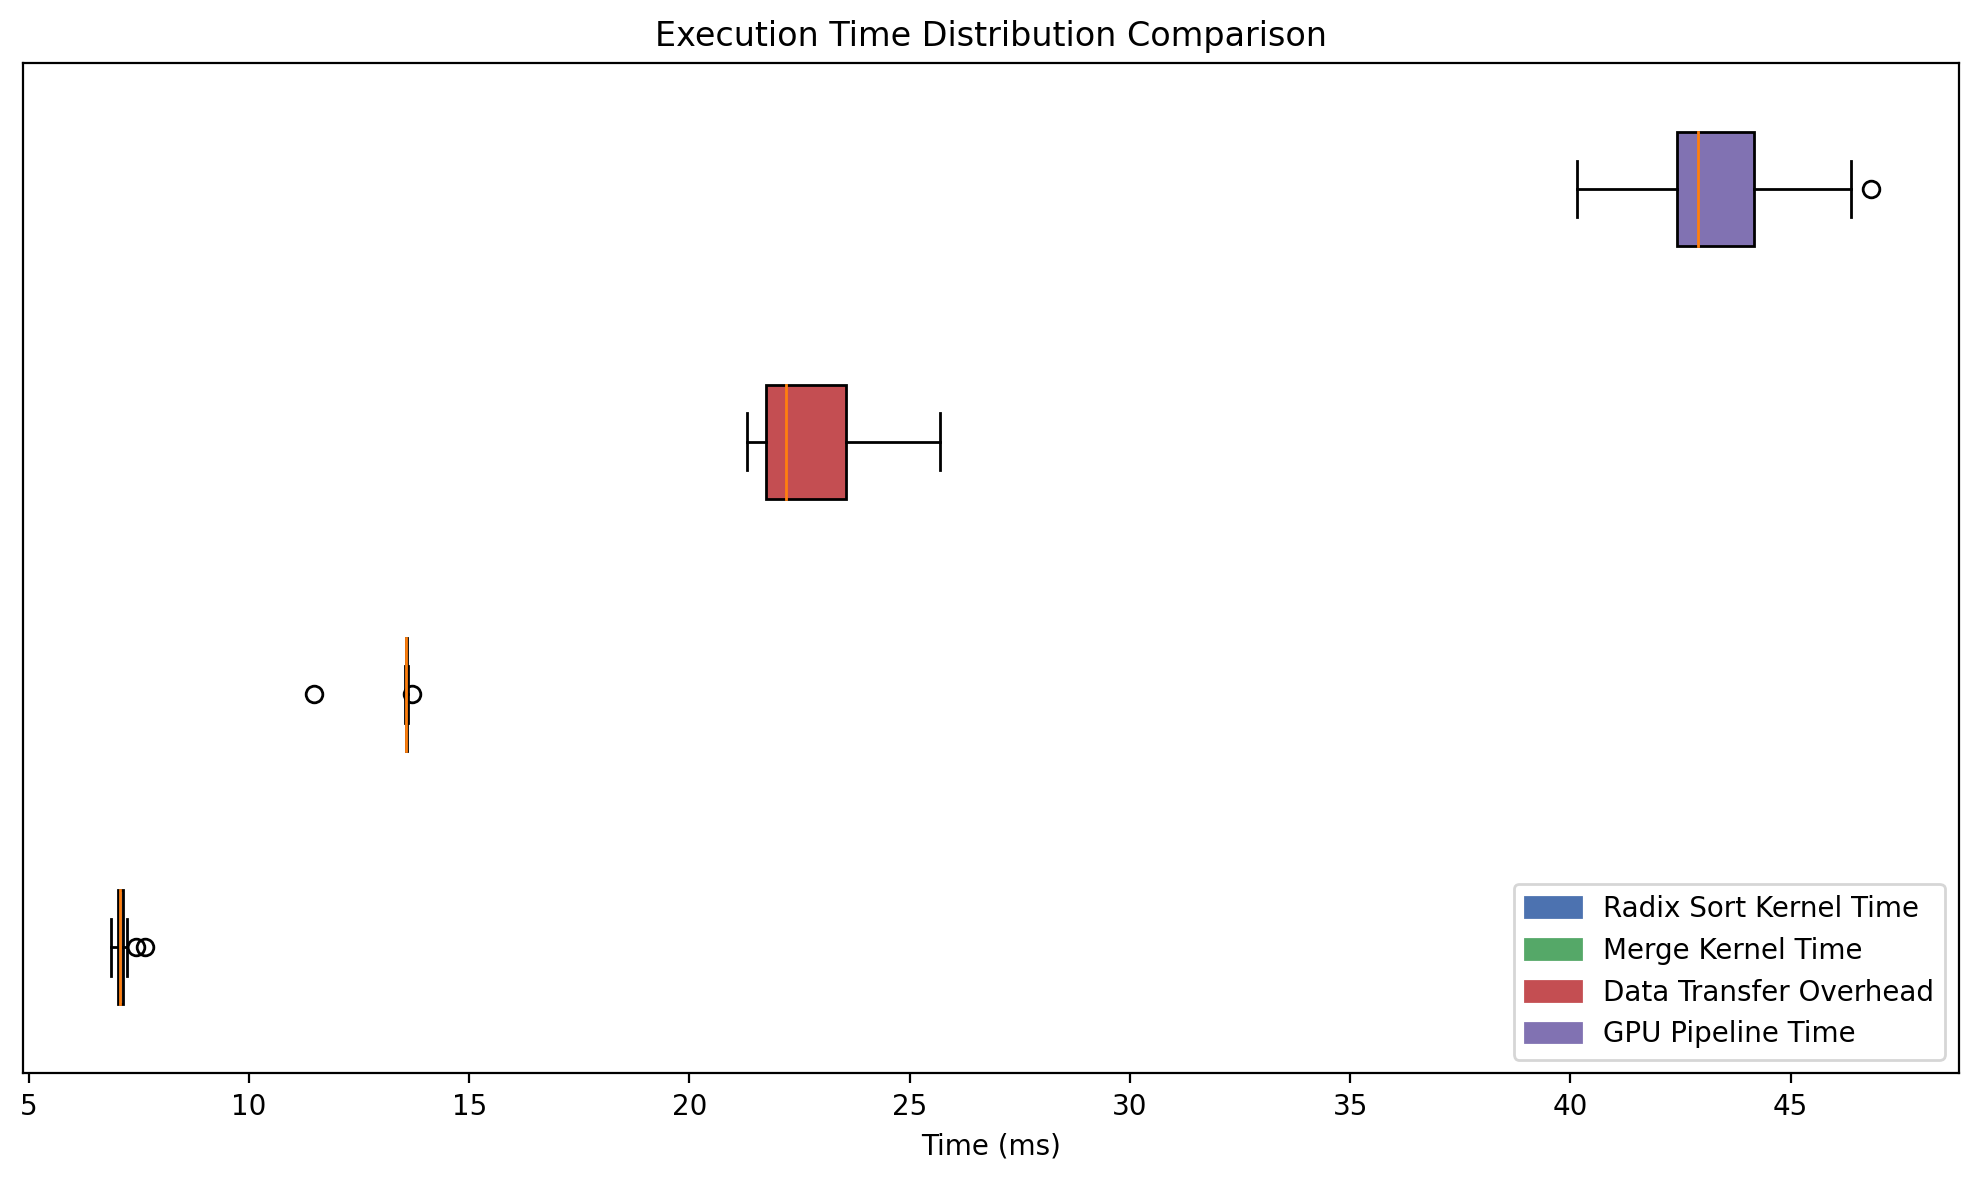

In [2]:
# Data
radix = [7.12,7.06,7.06,7.05,7.09,7.22,7,7.09,7.63,7.17,7.14,6.95,7.21,7.16,6.86,6.99,7.01,7.03,7.15,7.03,6.99,7.02,7.06,7.06,7.1,7.03,6.95,7.17,7.07,7.43]
merge = [13.6,13.56,13.57,13.54,13.57,13.59,13.56,13.54,13.57,13.7,13.56,13.58,13.6,13.6,13.56,13.56,13.59,13.57,13.56,13.6,13.57,13.56,13.56,13.55,13.57,13.56,11.48,13.58,13.56,13.6]
transfer = [23.07,22.13,23.6,24.81,23.95,22.13,23.77,23.56,25.62,23.58,25.68,23.38,21.68,21.3,23.46,21.57,21.34,21.62,23.15,21.38,22.05,21.94,23.5,22.25,21.73,21.63,21.73,21.79,23.49,21.81]
gpu = [43.79,42.75,44.23,45.4,44.61,42.94,44.33,44.19,46.82,44.45,46.38,43.91,42.49,42.06,43.88,42.12,41.94,42.22,43.86,42.01,42.61,42.52,44.12,42.86,42.4,42.22,40.16,42.54,44.12,42.84]

# Combine data
data = [radix, merge, transfer, gpu]
labels = [
    "Radix Sort Kernel Time",
    "Merge Kernel Time",
    "Data Transfer Overhead",
    "GPU Pipeline Time"
]

# Colors for each box
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# High-quality figure
plt.figure(figsize=(10, 6), dpi=200)

# Horizontal boxplot
box = plt.boxplot(
    data,
    vert=False,
    patch_artist=True
)

# Apply colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Remove y-axis ticks (since legend will describe them)
plt.yticks([])

# Labels and title
plt.xlabel("Time (ms)")
plt.title("Execution Time Distribution Comparison")

# Create legend manually
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for color, label in zip(colors, labels)
]
plt.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()

# Optional: save high-res image
plt.savefig("boxplot_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

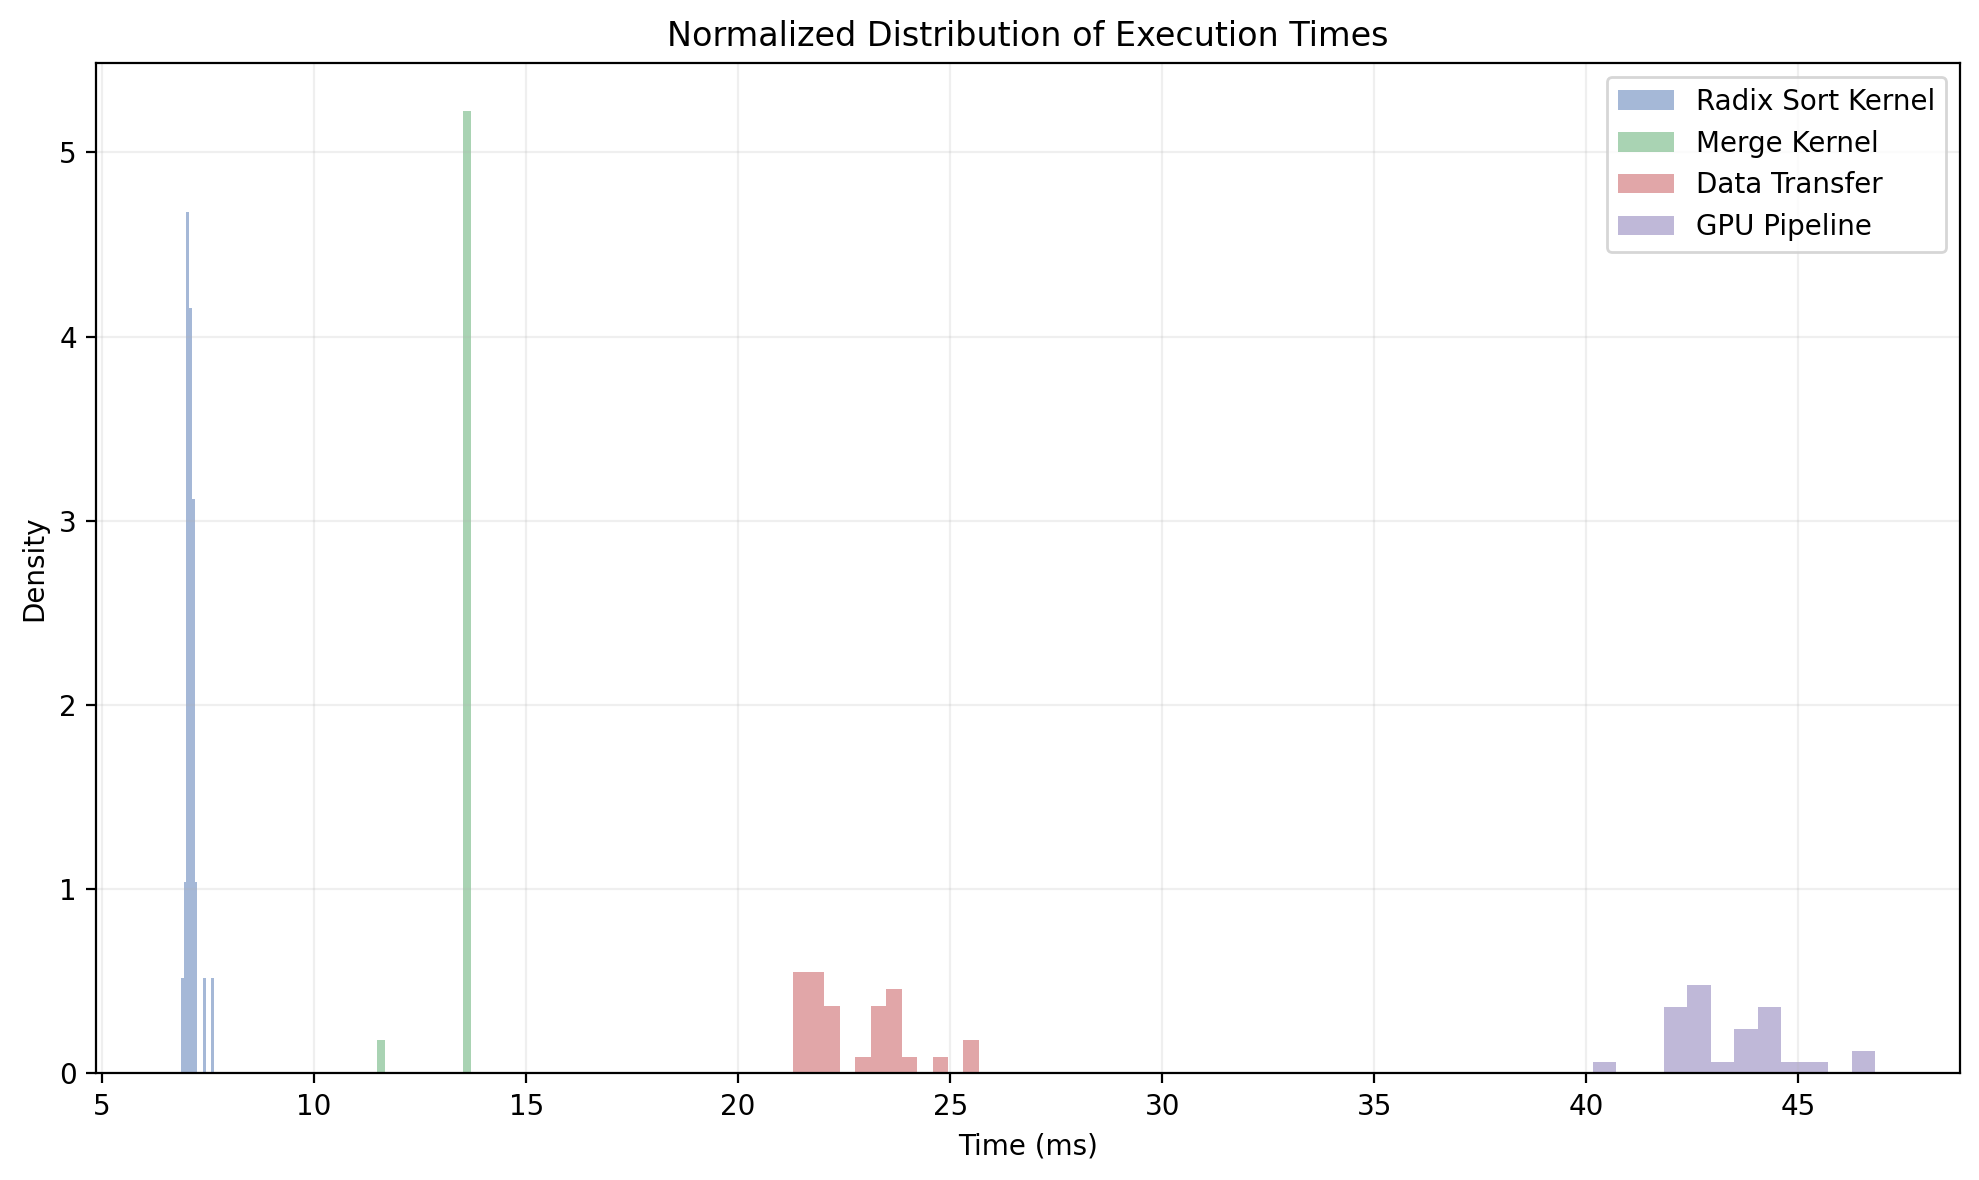

In [3]:
# Plot setup
plt.figure(figsize=(10, 6), dpi=200)

bins = 12  # consistent binning

# Histograms (normalized)
plt.hist(radix, bins=bins, alpha=0.5, density=True, label="Radix Sort Kernel", color="#4C72B0")
plt.hist(merge, bins=bins, alpha=0.5, density=True, label="Merge Kernel", color="#55A868")
plt.hist(transfer, bins=bins, alpha=0.5, density=True, label="Data Transfer", color="#C44E52")
plt.hist(gpu, bins=bins, alpha=0.5, density=True, label="GPU Pipeline", color="#8172B2")

# Labels and styling
plt.xlabel("Time (ms)")
plt.ylabel("Density")
plt.title("Normalized Distribution of Execution Times")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("histogram_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

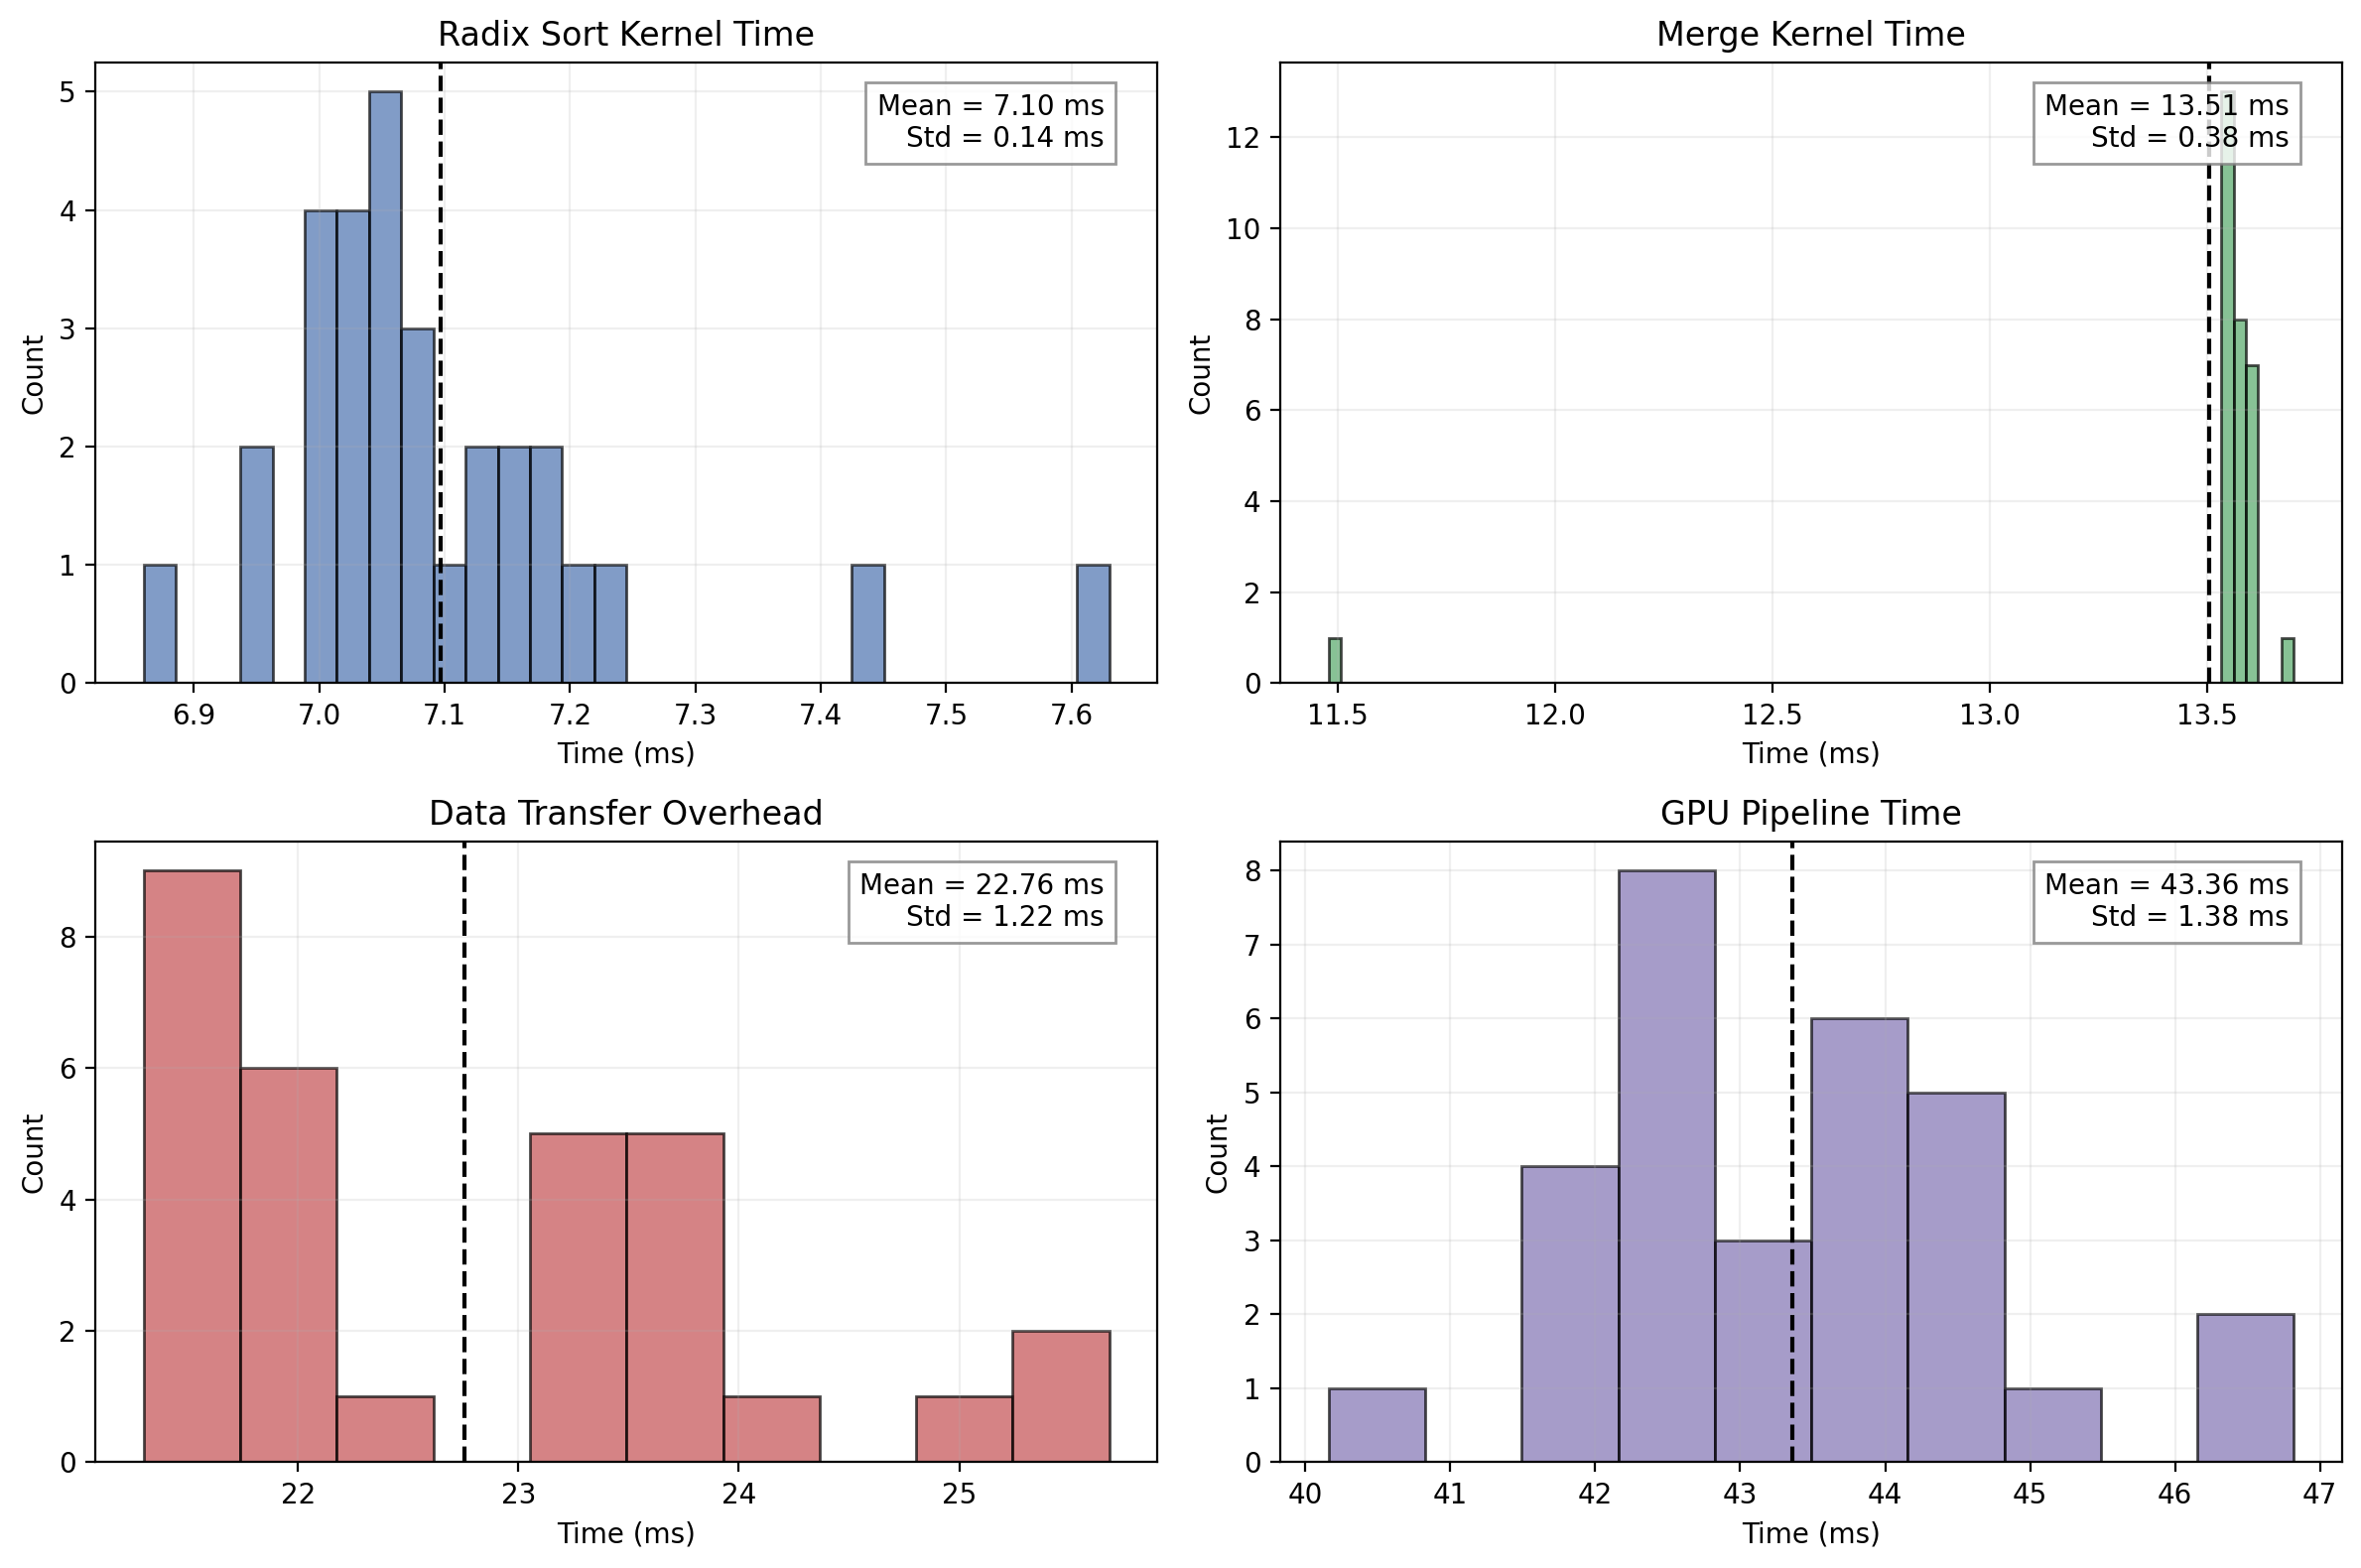

In [2]:
# Data
radix = np.array([7.12,7.06,7.06,7.05,7.09,7.22,7,7.09,7.63,7.17,7.14,6.95,7.21,7.16,6.86,6.99,7.01,7.03,7.15,7.03,6.99,7.02,7.06,7.06,7.1,7.03,6.95,7.17,7.07,7.43])
merge = np.array([13.6,13.56,13.57,13.54,13.57,13.59,13.56,13.54,13.57,13.7,13.56,13.58,13.6,13.6,13.56,13.56,13.59,13.57,13.56,13.6,13.57,13.56,13.56,13.55,13.57,13.56,11.48,13.58,13.56,13.6])
transfer = np.array([23.07,22.13,23.6,24.81,23.95,22.13,23.77,23.56,25.62,23.58,25.68,23.38,21.68,21.3,23.46,21.57,21.34,21.62,23.15,21.38,22.05,21.94,23.5,22.25,21.73,21.63,21.73,21.79,23.49,21.81])
gpu = np.array([43.79,42.75,44.23,45.4,44.61,42.94,44.33,44.19,46.82,44.45,46.38,43.91,42.49,42.06,43.88,42.12,41.94,42.22,43.86,42.01,42.61,42.52,44.12,42.86,42.4,42.22,40.16,42.54,44.12,42.84])

datasets = [radix, merge, transfer, gpu]
titles = [
    "Radix Sort Kernel Time",
    "Merge Kernel Time",
    "Data Transfer Overhead",
    "GPU Pipeline Time"
]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# --- Adjustable bin control ---
# You can tweak these individually if needed
bin_settings = [30, 80, 10, 10]
# Example: tighten radix if needed → [20, 10, 10, 10]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200)
axes = axes.flatten()

for i, (data, ax) in enumerate(zip(datasets, axes)):
    mean = np.mean(data)
    std = np.std(data)

    ax.hist(data, bins=bin_settings[i], color=colors[i], alpha=0.7, edgecolor='black')

    # Mean line
    ax.axvline(mean, color='black', linestyle='--', linewidth=1.5)

    # Titles and stats
    ax.set_title(titles[i])
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Count")

    # Annotate stats inside plot
    ax.text(
        0.95, 0.95,
        f"Mean = {mean:.2f} ms\nStd = {std:.2f} ms",
        transform=ax.transAxes,
        ha='right',
        va='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
    )

    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("separate_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

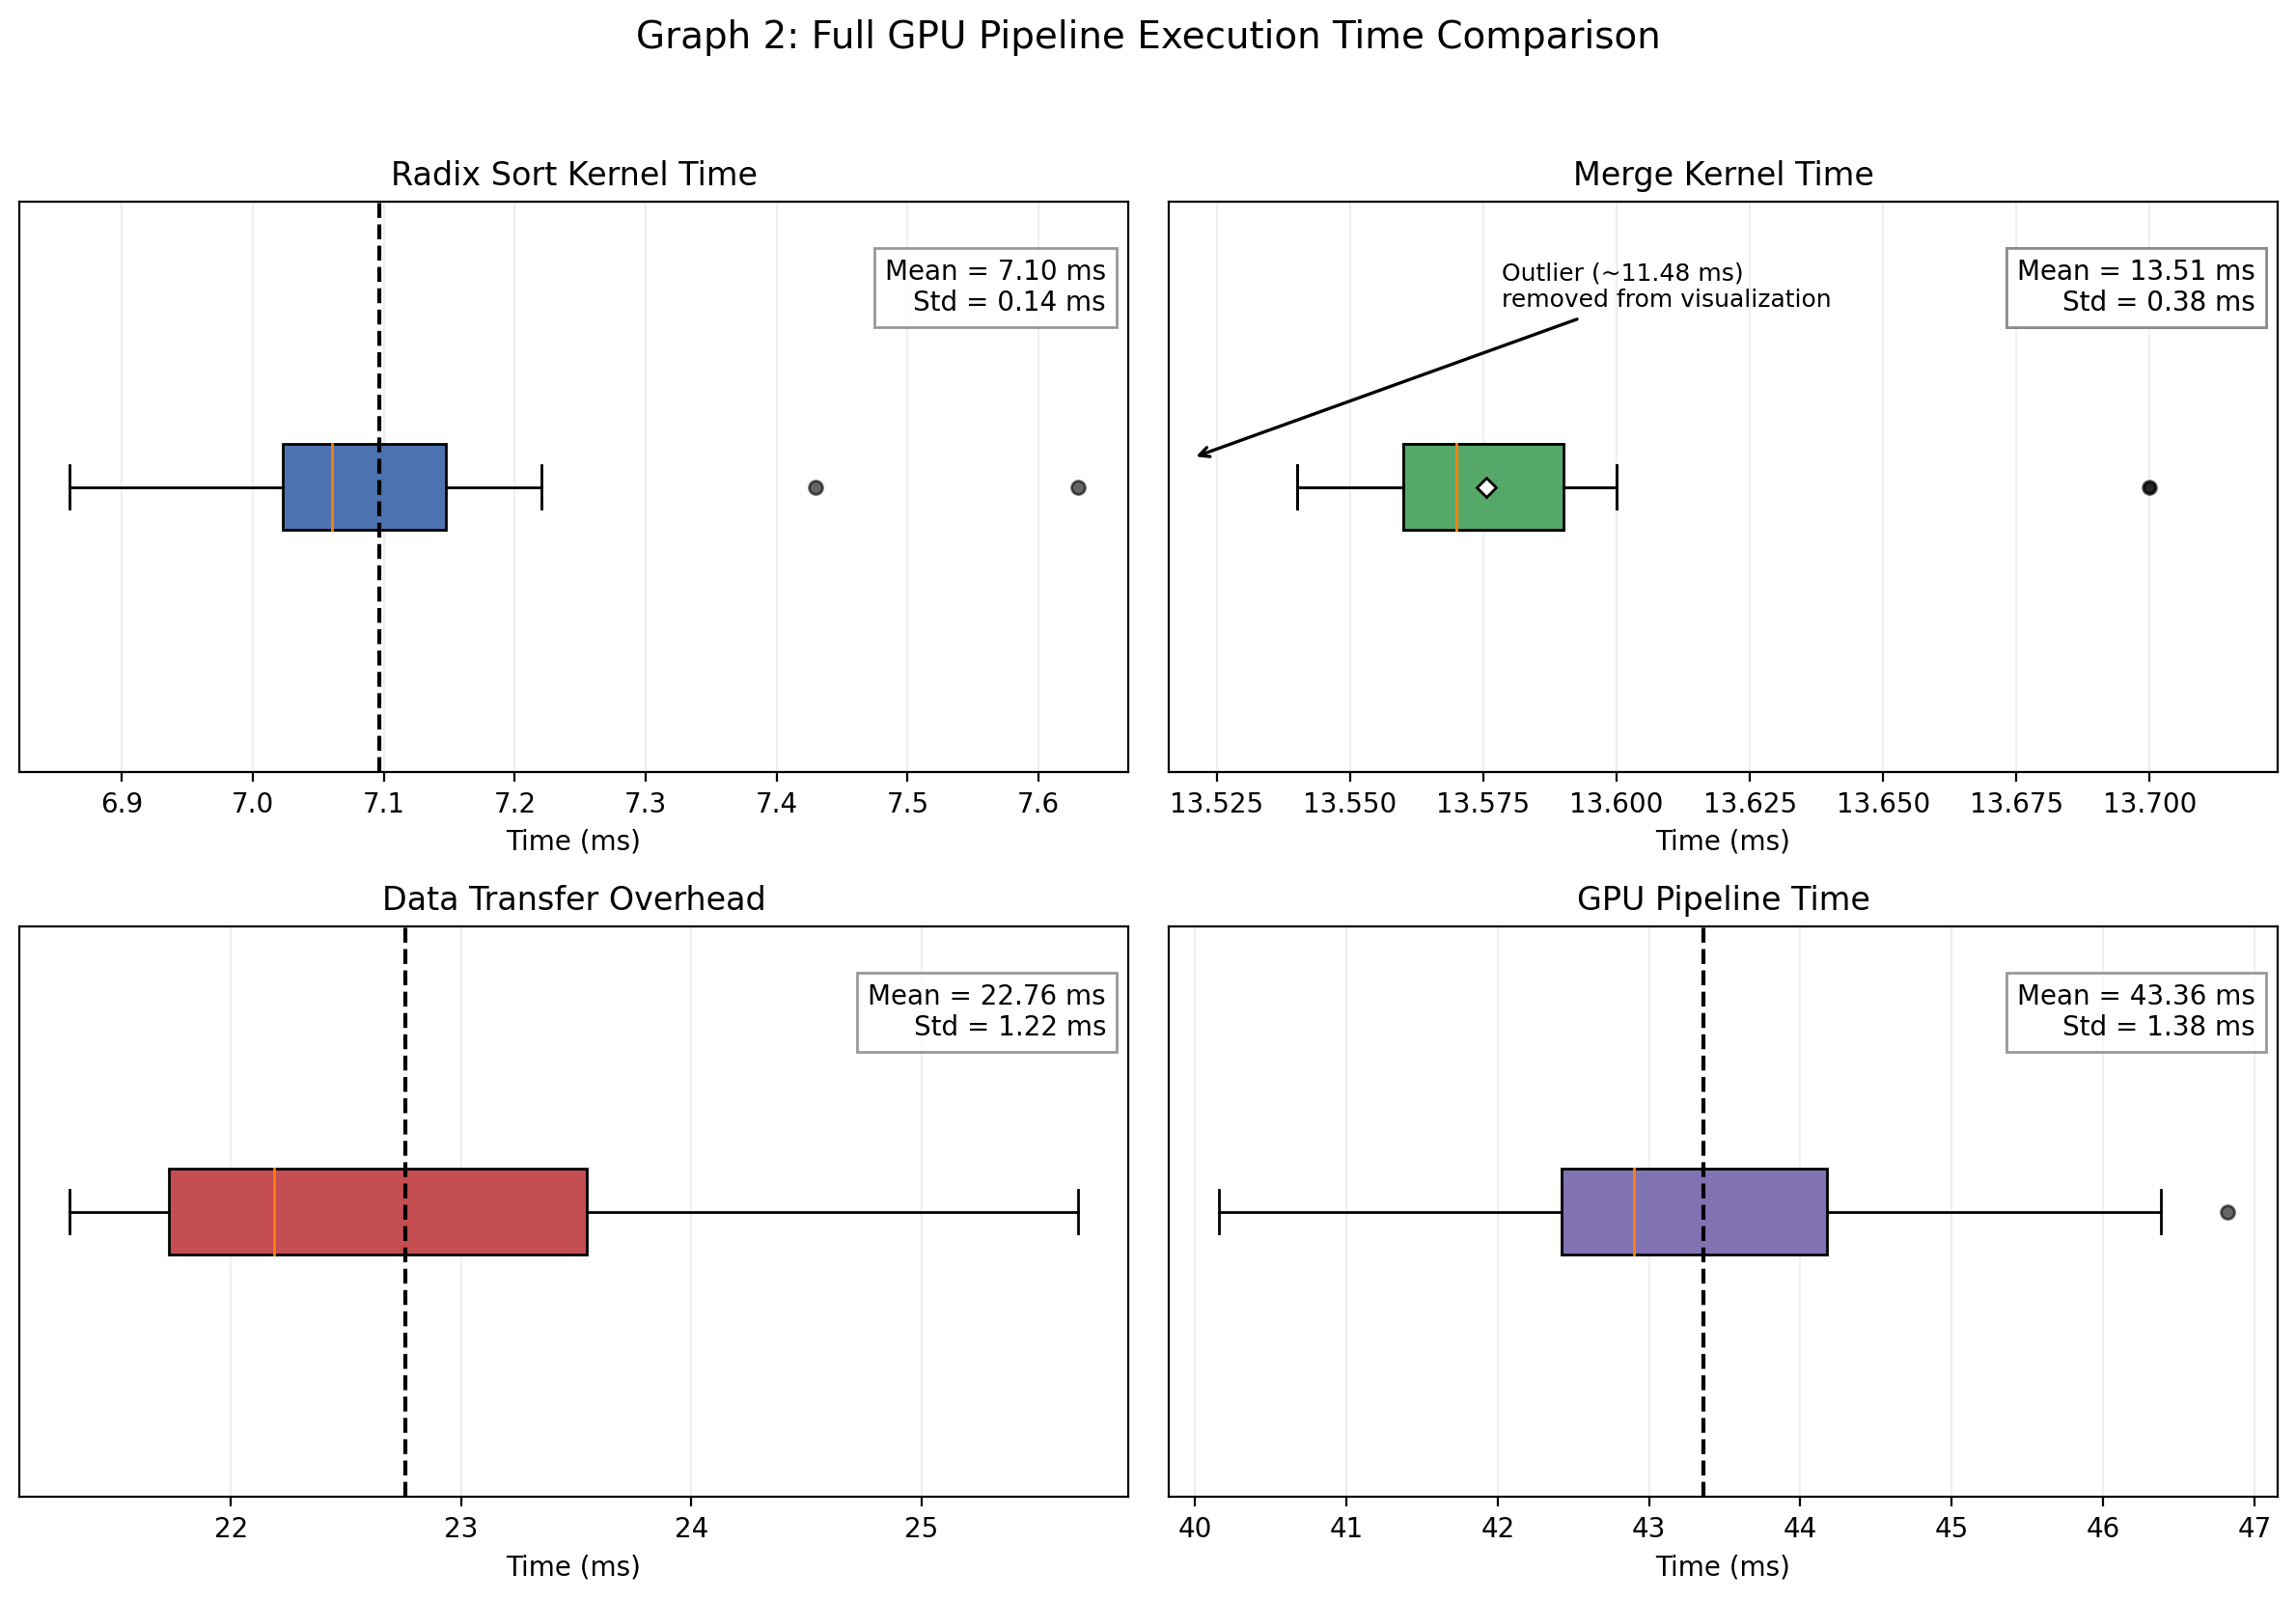

In [3]:
# Remove outlier ONLY for plotting
merge_filtered = merge[merge > 12]

datasets = [radix, merge_filtered, transfer, gpu]
titles = [
    "Radix Sort Kernel Time",
    "Merge Kernel Time",
    "Data Transfer Overhead",
    "GPU Pipeline Time"
]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200)
axes = axes.flatten()

for i, (data, ax) in enumerate(zip(datasets, axes)):
    # --- Stats ---
    if i == 1:
        mean = np.mean(merge)  # include outlier
        std = np.std(merge)
    else:
        mean = np.mean(data)
        std = np.std(data)

    # --- Boxplot ---
    box = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markersize=5, markerfacecolor='black', alpha=0.6)
    )

    box['boxes'][0].set_facecolor(colors[i])

    # Mean line
    ax.axvline(mean, color='black', linestyle='--', linewidth=1.5)

    ax.set_title(titles[i])
    ax.set_xlabel("Time (ms)")
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.2)

    # Stats text
    ax.text(
        0.98, 0.9,
        f"Mean = {mean:.2f} ms\nStd = {std:.2f} ms",
        transform=ax.transAxes,
        ha='right',
        va='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
    )
    ax.patch.set_alpha(0)

# --- Fix the merge subplot axis + annotation ---
merge_ax = axes[1]

# Cleaned data for visualization only
merge_filtered = merge[merge > 12]

# Stats (still include outlier)
mean = np.mean(merge)
std = np.std(merge)

# Boxplot (make structure more visible)
box = merge_ax.boxplot(
    merge_filtered,
    vert=False,
    patch_artist=True,
    showfliers=True,
    showmeans=True,  # helps reveal structure when variance is small
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=5),
    flierprops=dict(marker='o', markersize=4, markerfacecolor='black', alpha=0.6)
)

box['boxes'][0].set_facecolor("#55A868")

# Mean line (true mean including outlier)
merge_ax.axvline(mean, color='black', linestyle='--', linewidth=1.5)

# Axis padding (IMPORTANT: gives visual breathing room)
pad = 0.15 * (merge_filtered.max() - merge_filtered.min())
merge_ax.set_xlim(merge_filtered.min() - pad, merge_filtered.max() + pad)

merge_ax.set_title("Merge Kernel Time")
merge_ax.set_xlabel("Time (ms)")
merge_ax.set_yticks([])
merge_ax.grid(axis='x', alpha=0.2)

# Stats box
merge_ax.text(
    0.98, 0.9,
    f"Mean = {mean:.2f} ms\nStd = {std:.2f} ms",
    transform=merge_ax.transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

# Annotation (kept stable and visible)
merge_ax.annotate(
    "Outlier (~11.48 ms)\nremoved from visualization",
    xy=(0.02, 0.55),              # arrow head (left side)
    xycoords='axes fraction',

    xytext=(0.30, 0.85),          # text in top ~25%
    textcoords='axes fraction',

    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1.2
    ),

    fontsize=9,
    ha='left',
    va='center'
)

fig.suptitle(
    "Graph 2: Full GPU Pipeline Execution Time Comparison",
    fontsize=14,
    # fontweight='bold',
    y=1.03
)
fig.patch.set_alpha(0)

plt.savefig(
    "gpu_cpu_broken_hist.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True
)
plt.tight_layout()
plt.savefig("horizontal_boxplots_with_annotation.png", dpi=300, bbox_inches='tight')
plt.show()

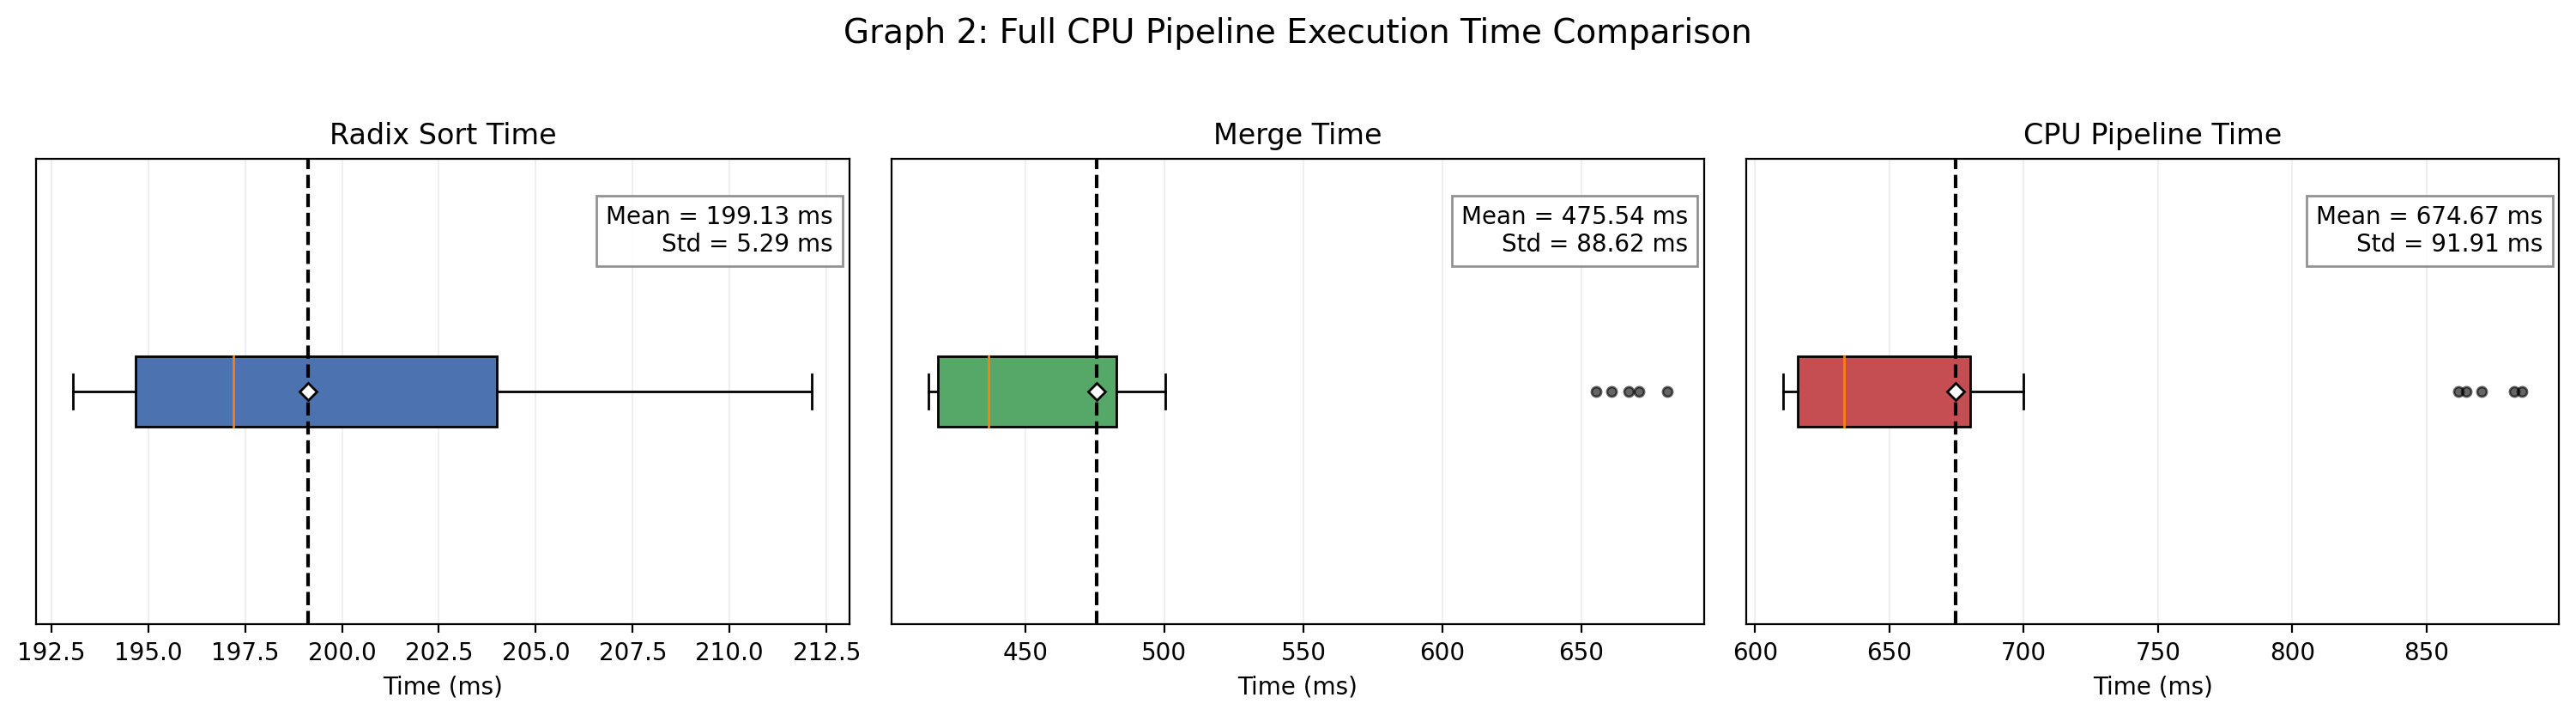

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Data
# ------------------------
radix = np.array([
199.34,195.33,197.43,206.8,212.13,204.88,204.09,207.37,203.72,195.38,
199.63,196.96,208.13,193.07,195.59,198.33,194.56,205.46,194.63,193.68,
197.51,193.83,194.79,194.21,195.8,202.76,193.62,196.43,204.39,194.17
])

merge = np.array([
445.46,440.87,420.89,655.25,670.67,680.81,660.84,438.89,666.88,442.6,
500.36,428.95,415.43,419.55,434.51,452.89,416.01,451.12,420.34,417.28,
483.14,416.82,429.7,417.46,484.79,418.15,418.47,482.06,415.19,420.79
])

cpu = np.array([
644.8,636.2,618.32,862.05,882.8,885.69,864.93,646.26,870.6,637.98,
699.99,625.91,623.56,612.62,630.1,651.22,610.57,656.58,614.97,610.96,
680.65,610.65,624.49,611.67,680.59,620.91,612.09,678.49,619.58,614.96
])

datasets = [radix, merge, cpu]

titles = [
    "Radix Sort Time",
    "Merge Time",
    "CPU Pipeline Time"
]

colors = ["#4C72B0", "#55A868", "#C44E52"]

# ------------------------
# Plot
# ------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200)

for i, (data, ax) in enumerate(zip(datasets, axes)):
    mean = np.mean(data)
    std = np.std(data)

    # Boxplot
    box = ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        showfliers=True,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='white',
                       markeredgecolor='black', markersize=5),
        flierprops=dict(marker='o', markersize=4,
                        markerfacecolor='black', alpha=0.6)
    )

    box['boxes'][0].set_facecolor(colors[i])

    # Mean line
    ax.axvline(mean, color='black', linestyle='--', linewidth=1.5)

    # Titles
    ax.set_title(titles[i])
    ax.set_xlabel("Time (ms)")
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.2)

    # Stats box
    ax.text(
        0.98, 0.9,
        f"Mean = {mean:.2f} ms\nStd = {std:.2f} ms",
        transform=ax.transAxes,
        ha='right',
        va='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
    )
    ax.patch.set_alpha(0)

fig.suptitle(
    "Graph 2: Full CPU Pipeline Execution Time Comparison",
    fontsize=14,
    # fontweight='bold',
    y=1.03
)
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
ax2.patch.set_alpha(0)

plt.savefig(
    "gpu_cpu_broken_hist.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True
)
plt.tight_layout()
plt.savefig("cpu_pipeline_boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

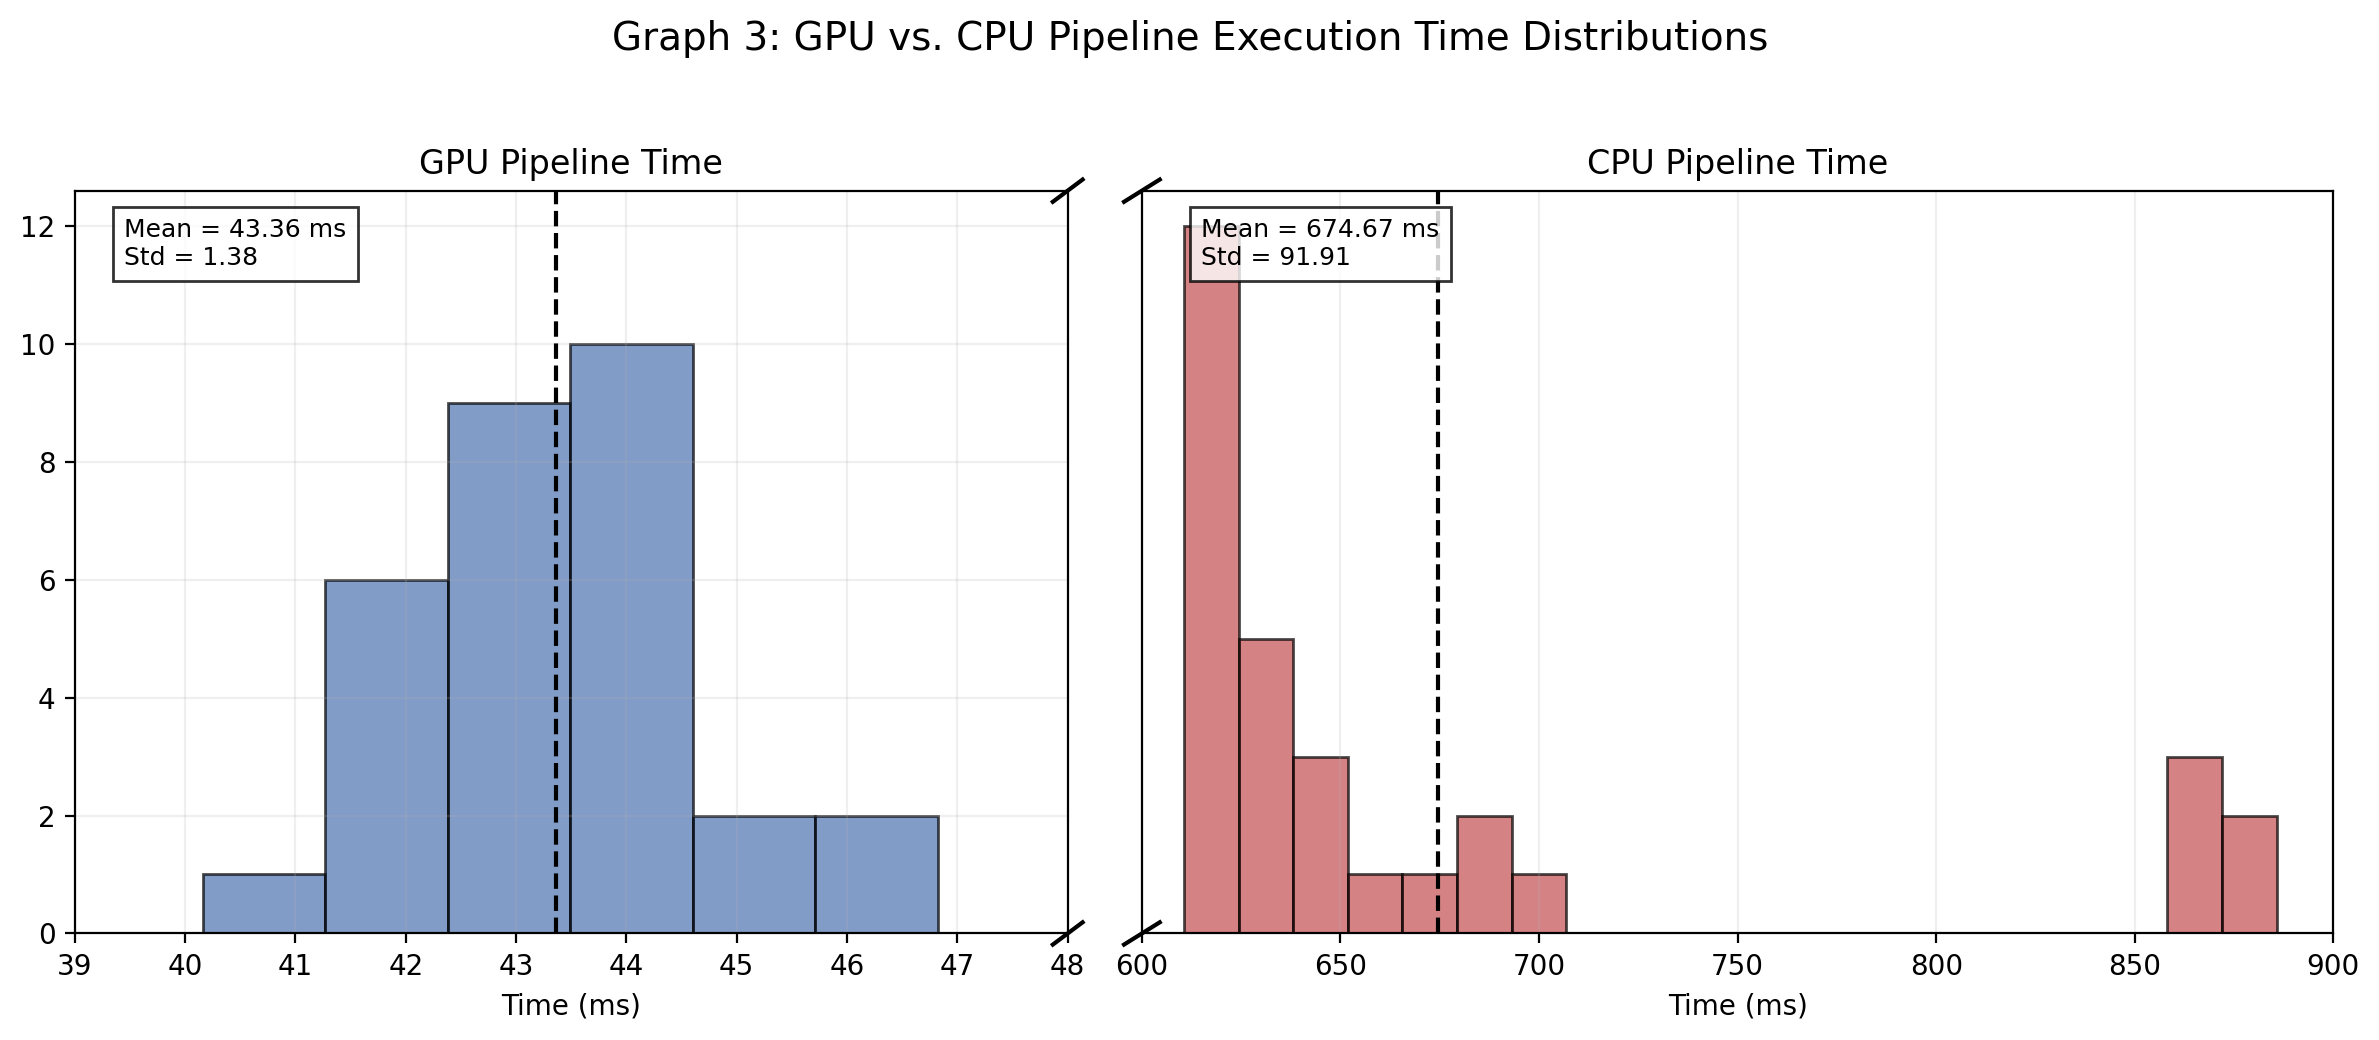

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Data
# -----------------------
gpu = np.array([
43.79,42.75,44.23,45.4,44.61,42.94,44.33,44.19,46.82,44.45,
46.38,43.91,42.49,42.06,43.88,42.12,41.94,42.22,43.86,42.01,
42.61,42.52,44.12,42.86,42.4,42.22,40.16,42.54,44.12,42.84
])

cpu = np.array([
644.8,636.2,618.32,862.05,882.8,885.69,864.93,646.26,870.6,637.98,
699.99,625.91,623.56,612.62,630.1,651.22,610.57,656.58,614.97,610.96,
680.65,610.65,624.49,611.67,680.59,620.91,612.09,678.49,619.58,614.96
])

# -----------------------
# Figure with broken axis
# -----------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(12, 5),
    dpi=200,
    gridspec_kw={'width_ratios': [1, 1.2]}
)


bins_gpu = 6
bins_cpu = 20

# -----------------------
# GPU histogram (left)
# -----------------------
ax1.hist(gpu, bins=bins_gpu, color="#4C72B0", alpha=0.7, edgecolor='black')
ax1.set_xlim(39, 48)
ax1.set_xlabel("Time (ms)")
ax1.set_title("GPU Pipeline Time")
ax1.grid(alpha=0.2)

# -----------------------
# CPU histogram (right)
# -----------------------
ax2.hist(cpu, bins=bins_cpu, color="#C44E52", alpha=0.7, edgecolor='black')
ax2.set_xlim(600, 900)
ax2.set_xlabel("Time (ms)")
ax2.set_title("CPU Pipeline Time")
ax2.grid(alpha=0.2)

# -----------------------
# Remove redundant y-axis
# -----------------------
ax2.yaxis.set_visible(False)

# -----------------------
# Add axis break markers (//)
# -----------------------
d = 0.015  # size of diagonal lines

kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# -----------------------
# Mean annotations
# -----------------------
ax1.axvline(np.mean(gpu), color='black', linestyle='--', linewidth=1.5)
ax2.axvline(np.mean(cpu), color='black', linestyle='--', linewidth=1.5)

ax1.text(
    0.05, 0.9,
    f"Mean = {np.mean(gpu):.2f} ms\nStd = {np.std(gpu):.2f}",
    transform=ax1.transAxes,
    bbox=dict(facecolor='white', alpha=0.8),
    fontsize=9
)

ax2.text(
    0.05, 0.9,
    f"Mean = {np.mean(cpu):.2f} ms\nStd = {np.std(cpu):.2f}",
    transform=ax2.transAxes,
    bbox=dict(facecolor='white', alpha=0.8),
    fontsize=9
)
fig.suptitle(
    "Graph 3: GPU vs. CPU Pipeline Execution Time Distributions",
    fontsize=14,
    # fontweight='bold',
    y=1.03
)
fig.patch.set_alpha(0)
ax1.patch.set_alpha(0)
ax2.patch.set_alpha(0)

plt.tight_layout()
plt.savefig("gpu_cpu_broken_hist.png", dpi=300, bbox_inches='tight')
plt.show()

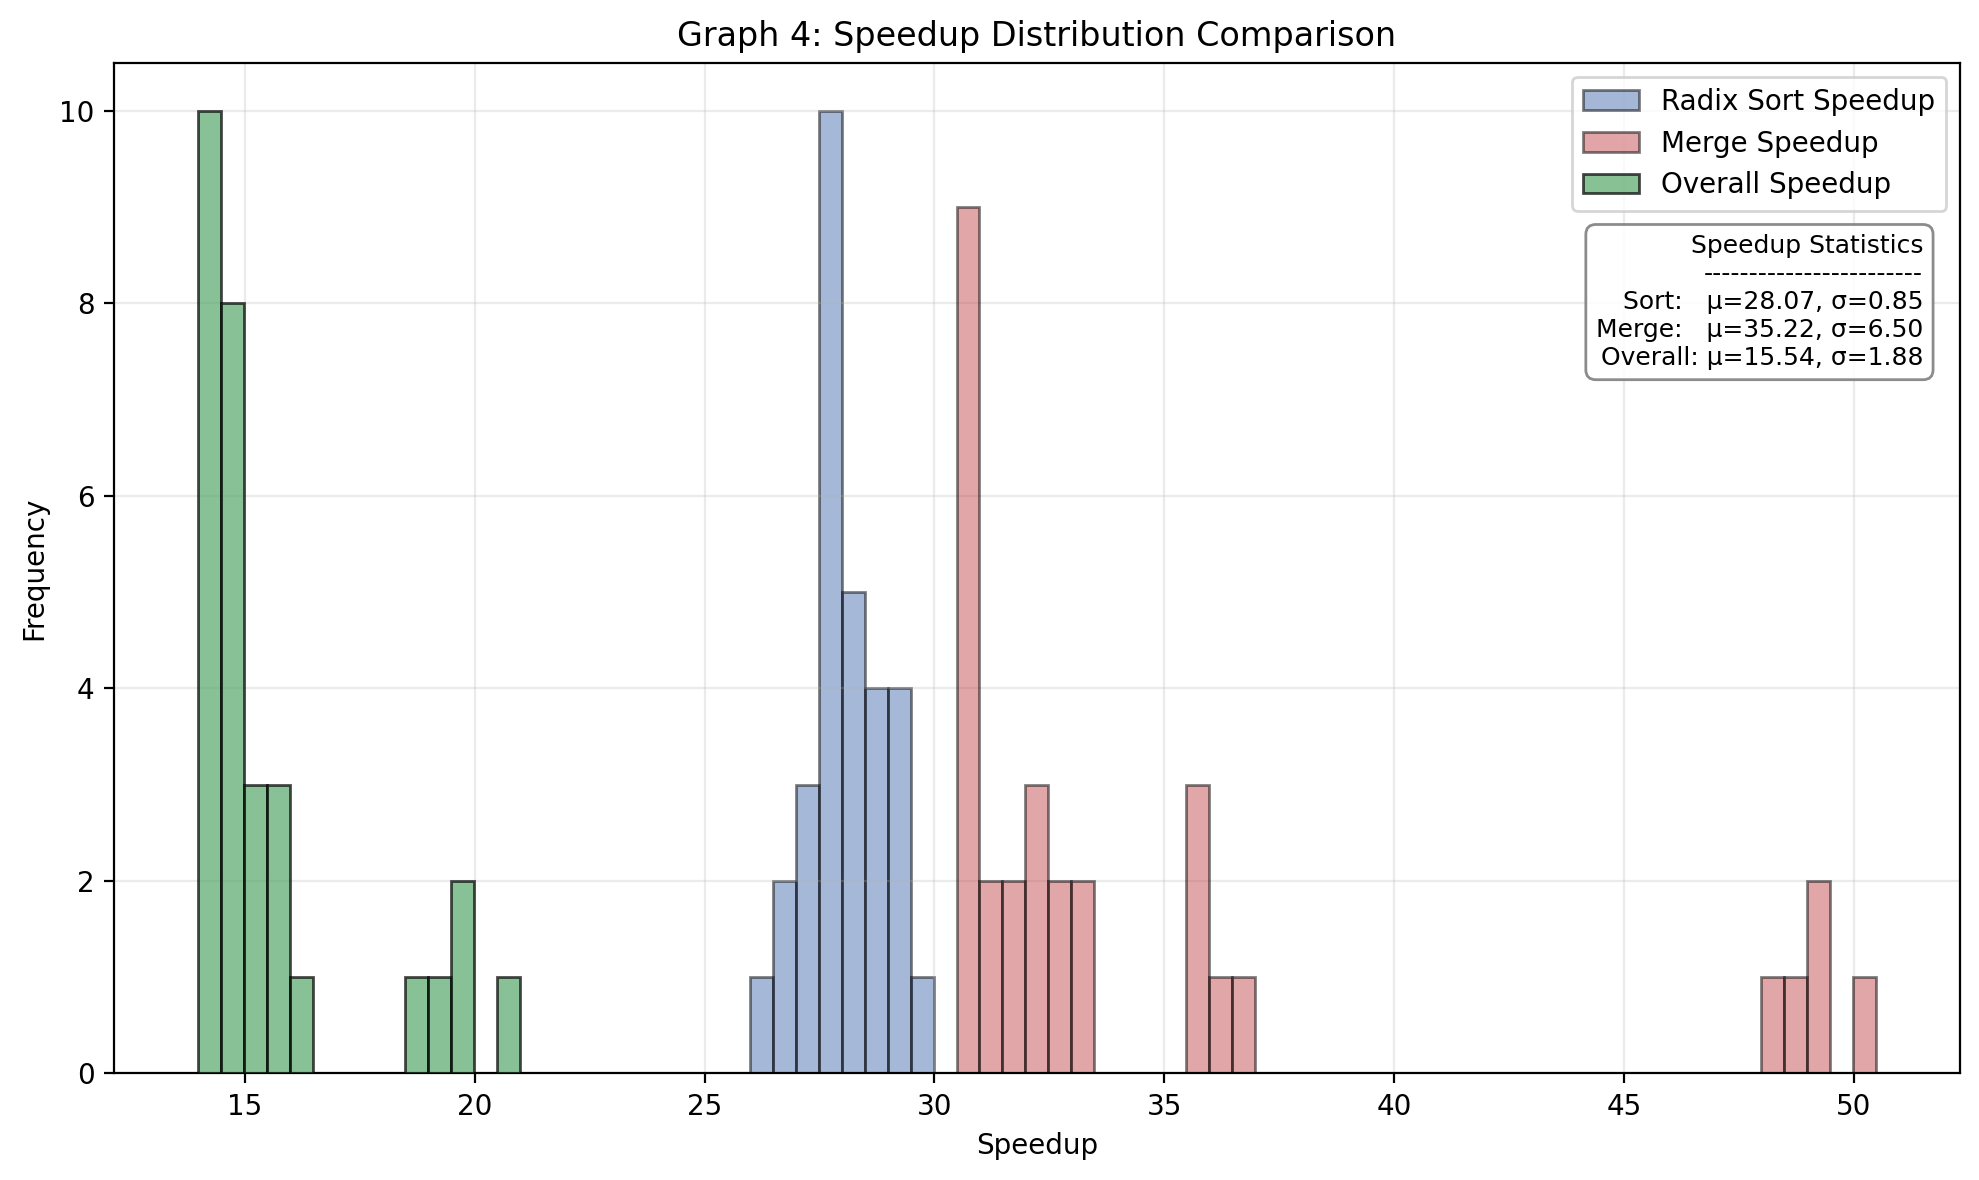

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Data
# -----------------------
radix = np.array([
28.00,27.67,27.96,29.33,29.92,28.38,29.16,29.25,26.70,27.25,
27.96,28.34,28.87,26.97,28.51,28.37,27.75,29.23,27.22,27.55,
28.26,27.61,27.59,27.51,27.58,28.84,27.86,27.40,28.91,26.13
])

merge = np.array([
32.75,32.51,31.02,48.39,49.42,50.10,48.73,32.41,49.14,32.31,
36.90,31.59,30.55,30.85,32.04,33.40,30.61,33.24,31.00,30.68,
35.60,30.74,31.69,30.81,35.73,30.84,36.45,35.50,30.62,30.94
])

overall = np.array([
14.72,14.88,13.98,18.99,19.79,20.63,19.51,14.62,18.59,14.35,
15.09,14.25,14.68,14.57,14.36,15.46,14.56,15.55,14.02,14.54,
15.97,14.36,14.15,14.27,16.05,14.71,15.24,15.95,14.04,14.35
])

# -----------------------
# Bin control (IMPORTANT)
# -----------------------
bin_width = 0.5  # adjust granularity here

all_data = np.concatenate([radix, merge, overall])
bins = np.arange(all_data.min(), all_data.max() + bin_width, bin_width)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10, 6), dpi=200)
fig = plt.gcf()
ax = plt.gca()

plt.hist(radix, bins=bins, alpha=0.5, color="#4C72B0",
         label="Radix Sort Speedup", edgecolor='black', zorder=1)

plt.hist(merge, bins=bins, alpha=0.5, color="#C44E52",
         label="Merge Speedup", edgecolor='black', zorder=2)

plt.hist(overall, bins=bins, alpha=0.7, color="#55A868",
         label="Overall Speedup", edgecolor='black', zorder=3)

def stats(arr):
    return np.mean(arr), np.std(arr)

radix_mean, radix_std = stats(radix)
merge_mean, merge_std = stats(merge)
overall_mean, overall_std = stats(overall)

stats_text = (
    "Speedup Statistics\n"
    "------------------------\n"
    f"Sort:   μ={radix_mean:.2f}, σ={radix_std:.2f}\n"
    f"Merge:   μ={merge_mean:.2f}, σ={merge_std:.2f}\n"
    f"Overall: μ={overall_mean:.2f}, σ={overall_std:.2f}"
)
# -----------------------
# Styling
# -----------------------
plt.xlabel("Speedup")
plt.ylabel("Frequency")
plt.title("Graph 4: Speedup Distribution Comparison")

plt.legend()
plt.grid(alpha=0.25)

plt.gca().text(
    0.98, 0.83,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.tight_layout()
plt.savefig("speedup_triple_hist.png", dpi=300, bbox_inches='tight')
plt.show()